## <center>Import des modules</center>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline

## <center>Création de notre DataSet</center>

In [2]:
df = pd.read_csv('./datasets/Pakistan Largest Ecommerce Dataset.csv', low_memory=False, na_values = [' ', '\\N', 'NaN '])
pd.set_option('display.max_columns', None)

## <center>Première exploration du Dataset</center>

#### Contexte du projet

On a ici un tableau qui résume les transactions de commerce électronique au Pakistan sur la période mars 2016 à août 2018. Ces données ont été collectées auprès de divers marchands de commerce électronique dans le cadre d'une étude de recherche.


In [3]:
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,NaN,0.0,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,NaN,0.0,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,NaN,0.0,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,300.0,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,NaN,0.0,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584505 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        576510 non-null  object 
 9   sales_commission_code  108348 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [5]:
df.describe()

,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,584524.000000,5.845240e+05,584524.000000,5.845240e+05,584524.000000,584524.000000,584524.000000,584513.000000,0.0,0.0,0.0,0.0,0.0
mean,565667.074218,6.348748e+03,1.296388,8.530619e+03,499.492775,2017.044115,7.167654,45790.511965,NaN,NaN,NaN,NaN,NaN
std,200121.173648,1.494927e+04,3.996061,6.132081e+04,1506.943046,0.707355,3.486305,34414.962389,NaN,NaN,NaN,NaN,NaN
min,211131.000000,0.000000e+00,1.000000,-1.594000e+03,-599.500000,2016.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,395000.750000,3.600000e+02,1.000000,9.450000e+02,0.000000,2017.000000,4.000000,13516.000000,NaN,NaN,NaN,NaN,NaN
50%,568424.500000,8.990000e+02,1.000000,1.960400e+03,0.000000,2017.000000,7.000000,42856.000000,NaN,NaN,NaN,NaN,NaN
75%,739106.250000,4.070000e+03,1.000000,6.999000e+03,160.500000,2018.000000,11.000000,73536.000000,NaN,NaN,NaN,NaN,NaN
max,905208.000000,1.012626e+06,1000.000000,1.788800e+07,90300.000000,2018.000000,12.000000,115326.000000,NaN,NaN,NaN,NaN,NaN


#### Explication des variables principales :

SKU: Codes articles

increment_id : Numéro de la commande

discount_amount : Montant de l'offre de réduction

sales_commission_code :  Cette colonne renseigne un code pouvant se traduire comme étant l'id de l'enseigne de vente

Working Date : doublon d’information par rapport à la colonne ‘created at’

BI status : indication concernant le déroulement stratégico-marketing de la transaction.

status : Statut actuel de la transaction

MV : Prix net avant réduction

M-Y : Mois-Année. Nous pensons que cette colonne peut être supprimée car il existe déjà une colonne ‘year’ et une colonne ‘Month’.

FY : idem que pour la colonne M-Y donc à supprimer

## <center>Nettoyage du DataSet</center>



Nous proposons dans un premier temps de supprimer les 5 dernières colonnes "Unnamed" qui ne contiennent aucune information.
Nous constatons que les 464 051 dernières lignes correspondent à des lignes 100% N/A, nous allons donc les supprimer.
Enfin, nous supprimons les données inutiles pour le projet : 'sku', 'Working Date', 'FY' et 'M-Y' 

##### Suppression des 5 dernières colonnes


In [6]:
df = df.drop(['Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'], axis=1)

##### Recherche et suppression des doublons

In [7]:
df.duplicated().sum()

464050

In [8]:
df.drop_duplicates(inplace=True)

##### Suppression des données inutiles

In [9]:
df = df.drop(['sku', 'Working Date', 'FY', 'M-Y'], axis=1)

##### Harmonisation de la police des noms des colonnes

In [10]:
df.columns = df.columns.str.capitalize()

##### Gestion des NaN

In [11]:
df.isna().sum().sum()

484248

In [12]:
df.dropna(axis = 0, subset = ['Customer id', 'Sales_commission_code'], inplace = True)

In [13]:
df.isna().sum()

Item_id                     0
Status                      0
Created_at                  0
Price                       0
Qty_ordered                 0
Grand_total                 0
Increment_id                0
Category_name_1          1610
Sales_commission_code       0
Discount_amount             0
Payment_method              0
Bi status                   0
 mv                         0
Year                        0
Month                       0
Customer since              0
Customer id                 0
dtype: int64


Nous remarquons qu'il reste encore 1610 dans la variable 'category_name_1'.
Cette variable est justement une de nos variables cibles.

Ces 1610 NaN ne représentent que 0.27% de notre dataset. Cela représente une part négligeable, nous avons pris la décision de les supprimer.

In [14]:
df = df.dropna()

In [15]:
df.isna().sum().sum()

0

In [16]:
df.index = np.arange(df.shape[0])

##### Réorganisation des colonnes pour une meilleure lecture du dataset


In [17]:
df = df[['Customer id', 'Customer since', 'Item_id', 'Increment_id', 'Sales_commission_code', 'Qty_ordered',
         'Price', 'Discount_amount', 'Grand_total', 'Payment_method',
         'Created_at', 'Year', 'Month', 'Category_name_1', 'Bi status',  'Status']]

In [18]:
df.head(2)

,Customer id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Grand_total,Payment_method,Created_at,Year,Month,Category_name_1,Bi status,Status
0,4.0,2016-7,211135.0,100147446,R-FSD-52352,1.0,360.0,300.0,60.0,cod,7/1/2016,2016.0,7.0,Beauty & Grooming,Net,complete
1,11.0,2016-7,211145.0,100147455,105259,1.0,120.0,0.0,120.0,ublcreditcard,7/1/2016,2016.0,7.0,Home & Living,Net,complete


##### Formatage des données

In [19]:
len(df['Customer id'].unique())

13779

In [20]:
len(df['Sales_commission_code'].unique())

7174

In [21]:
df[['Customer id', 'Item_id', 'Qty_ordered', 'Increment_id']] = df[['Customer id', 'Item_id', 'Qty_ordered', 'Increment_id']].astype('int')

In [22]:
df[['Customer id', 'Item_id']] = df[['Customer id', 'Item_id']].astype('object')

In [23]:
df['Customer since'] = pd.to_datetime(df['Customer since']).dt.to_period('M')

In [24]:
df.rename({'Category_name_1':'Category', 'Grand_total':'Net_income',
          'Customer id':'Customer_id', 'Bi status':'Bi_status'}, axis =1, inplace=True)

In [25]:
df['Created_at'] = pd.to_datetime(df['Created_at'])

In [26]:
df['Year'] = df['Created_at'].dt.year

In [27]:
df['Month'] = df['Created_at'].dt.month

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 106738 entries, 0 to 106737
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer_id            106738 non-null  object        
 1   Customer since         106738 non-null  period[M]     
 2   Item_id                106738 non-null  object        
 3   Increment_id           106738 non-null  int64         
 4   Sales_commission_code  106738 non-null  object        
 5   Qty_ordered            106738 non-null  int64         
 6   Price                  106738 non-null  float64       
 7   Discount_amount        106738 non-null  float64       
 8   Net_income             106738 non-null  float64       
 9   Payment_method         106738 non-null  object        
 10  Created_at             106738 non-null  datetime64[ns]
 11  Year                   106738 non-null  int64         
 12  Month                  106738 non-null  int6

##### Regroupement et redéfinition des valeurs des variables

Afin de permettre une analyse plus cohérente des données, et compte tenu de la grande diversité des statuts présents, nous avons décidé de regrouper l’ensemble des statuts dans 3 grandes familles : finalisé, en attente et annulé.

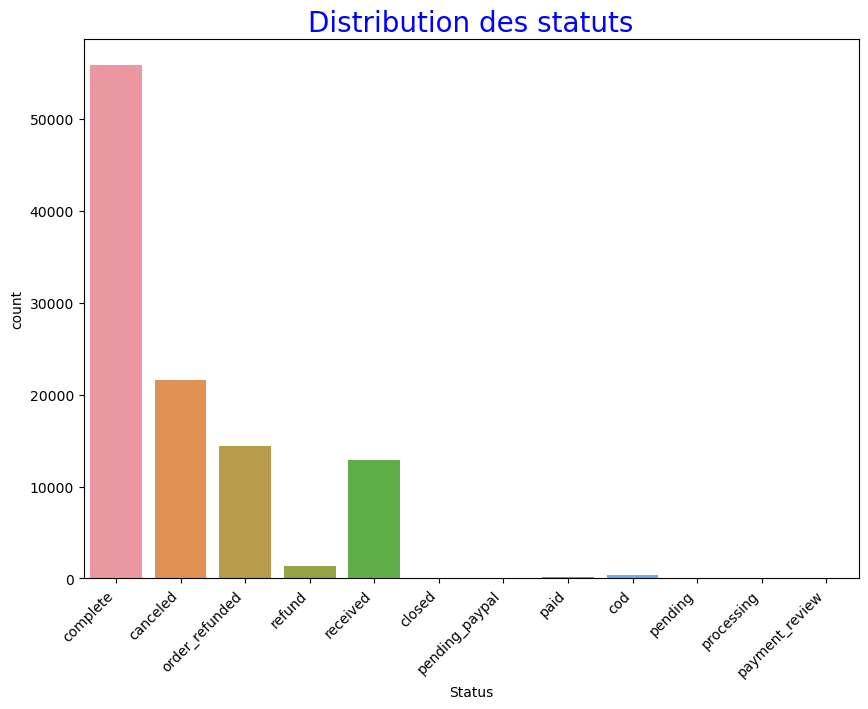

In [29]:
plt.figure(figsize=(10,7))
sns.countplot(df.Status)
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Distribution des statuts', fontsize=20, color='b');

In [30]:
df['Status'].unique()

array(['complete', 'canceled', 'order_refunded', 'refund', 'received',
       'closed', 'pending_paypal', 'paid', 'cod', 'pending', 'processing',
       'payment_review'], dtype=object)

finalisé = complete, closed, received, paid, exchange

en attente = pending, processing, pending_paypal, 'holded', 'payment_review', 'cod'

annulé = order_refunded, refund, fraud, canceled'

In [31]:
df['Regroupement_status'] = df['Status']

In [32]:
df['Regroupement_status'] = df['Regroupement_status'].replace(to_replace = ['complete', 'closed', 'received', 'paid', 'exchange'],
                                                              value = 'finalisé')


In [33]:
df['Regroupement_status'] = df['Regroupement_status'].replace(to_replace = ['payment_review', 'holded', 'pending', 'processing',
                                                  'pending_paypal', 'cod'], value = 'en attente')
                                                              

In [34]:
df['Regroupement_status'] = df['Regroupement_status'].replace(to_replace = ['canceled', 'order_refunded', 'refund', 'fraud'],
                                                              value = 'annulé')


In [35]:
df['Regroupement_status'].unique()

array(['finalisé', 'annulé', 'en attente'], dtype=object)

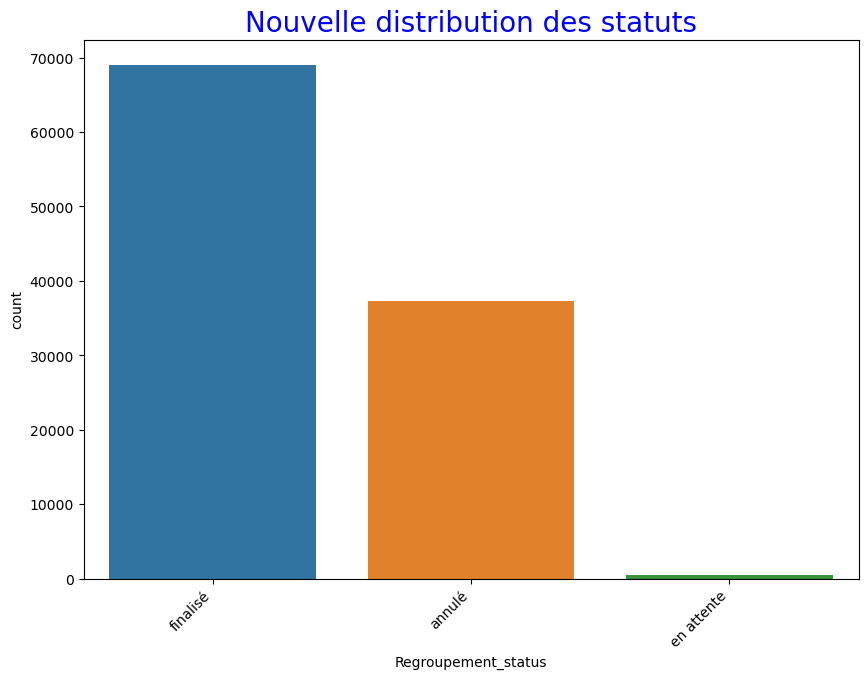

In [36]:
plt.figure(figsize=(10,7))
sns.countplot(df['Regroupement_status'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Nouvelle distribution des statuts', fontsize=20, color='b');

###### Regroupement et redéfinition des valeurs de la variable 'Payment_method'  : 

De la même manière que pour la variable "Status", nous regroupons les différentes valeurs de la variable "Payment_method" en cing catégories plus générales : 
- cod 
- paiement immédiat
- voucher
- paiement en plusieurs fois
- portefeuille en ligne


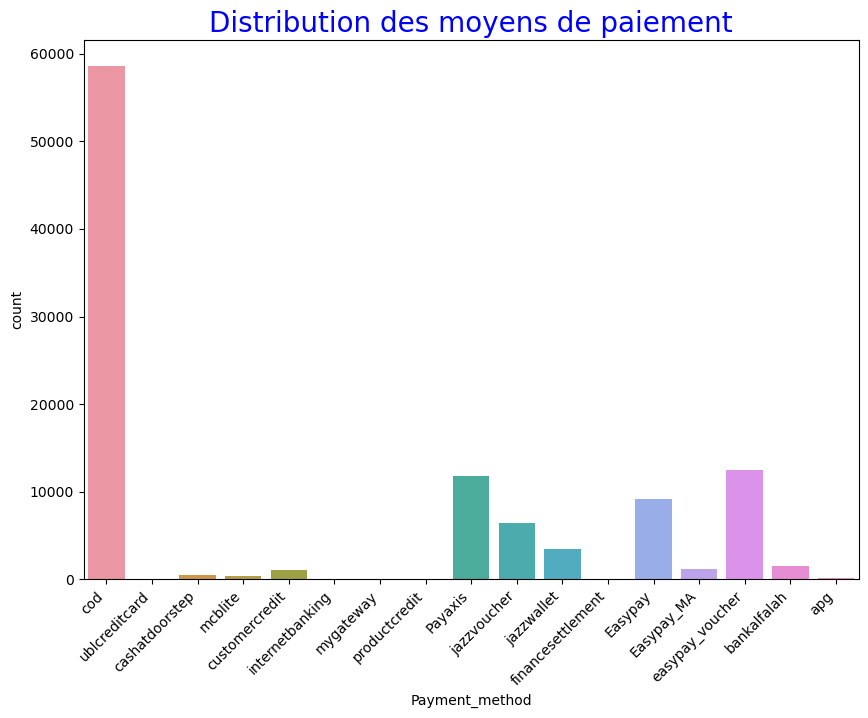

In [37]:
plt.figure(figsize=(10,7))
sns.countplot(df['Payment_method'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Distribution des moyens de paiement', fontsize=20, color='b');

In [38]:
len(df['Payment_method'].unique())

17

cod = cod, cashatdoorstep, financesettlement

paiement immédiat = Easypay, Easypay_MA, ublcreditcard, mygateway, mcblite, internetbanking, bankalfalah,

voucher = easypay_voucher, jazzvoucher,

paiement en plusieurs fois= customercredit, productcredit, Payaxis

portefeuille en ligne = jazzwallet , apg

La répartition et la définition des moyens de paiements sont les suivantes :

- 46.44 % Cod = Cash on delivery (paiement à la livraison)

- 0.08 %cashatdoorstep = paiement au pied de la porte

- 0.14% ublcreditcard = carte de crédit UBL(banque)

- 0.11 % mygateway = banque

- 13.02 % customercredit = crédit à la consommation

- 0.08% cashatdoorstep = paiement au pied de la porte

- 0.09% mcblite = banque en ligne pakistanaise

- 0.07% internetbanking = banque en ligne

- 0.01%productcredit = crédit à la consommation

- 5.95 %jazzwallet = (portefeuille en ligne) Solution facilitatrice pour le paiement en ligne

- 2.61% jazzvoucher = mode de paiement par Voucher

- 14.34% Easypay = Solution facilitatrice pour le paiement en ligne spécifique au marché Indien et Pakistanais

- 2.41 % Easypay_MA = (MA = Mobile account) Solution facilitatrice pour le paiement en ligne

- 5.39% easypay_voucher = mode paiement par Voucher

- 3.99% bankalfalah = banque pakistanaise

- 0.30% apg = avance de la banque

- 0.002% financesettlement = divers


In [39]:
df["Payment_method"].value_counts(normalize = True)

cod                  0.549045
easypay_voucher      0.116613
Payaxis              0.111029
Easypay              0.085799
jazzvoucher          0.060522
jazzwallet           0.032912
bankalfalah          0.014044
Easypay_MA           0.010924
customercredit       0.009537
cashatdoorstep       0.004169
mcblite              0.003832
apg                  0.000928
internetbanking      0.000215
ublcreditcard        0.000197
mygateway            0.000141
financesettlement    0.000075
productcredit        0.000019
Name: Payment_method, dtype: float64

In [40]:
categ = {"cashatdoorstep": "cod", "financesettlement": "cod",
         "ublcreditcard" : 'paiement immédiat',  'mygateway':'paiement immédiat', 'mcblite':'paiement immédiat', 
         'internetbanking':'paiement immédiat', 'bankalfalah':'paiement immédiat',
         'Easypay':'paiement immédiat', 'Easypay_MA':'paiement immédiat',
         'easypay_voucher':'voucher', 'jazzvoucher':'voucher',
         'customercredit':'Paiement en plusieurs fois', 'productcredit':'Paiement en plusieurs fois', 
         'Payaxis':'Paiement en plusieurs fois',
         'jazzwallet':'portefeuille en ligne', 'apg':'portefeuille en ligne'}


In [41]:
df['Regroupement_payment_method'] = df['Payment_method']

In [42]:
df['Regroupement_payment_method'].replace(categ, inplace=True)

In [43]:
df['Regroupement_payment_method'].unique()

array(['cod', 'paiement immédiat', 'Paiement en plusieurs fois',
       'voucher', 'portefeuille en ligne'], dtype=object)

In [44]:
df['Regroupement_payment_method'].unique()

array(['cod', 'paiement immédiat', 'Paiement en plusieurs fois',
       'voucher', 'portefeuille en ligne'], dtype=object)

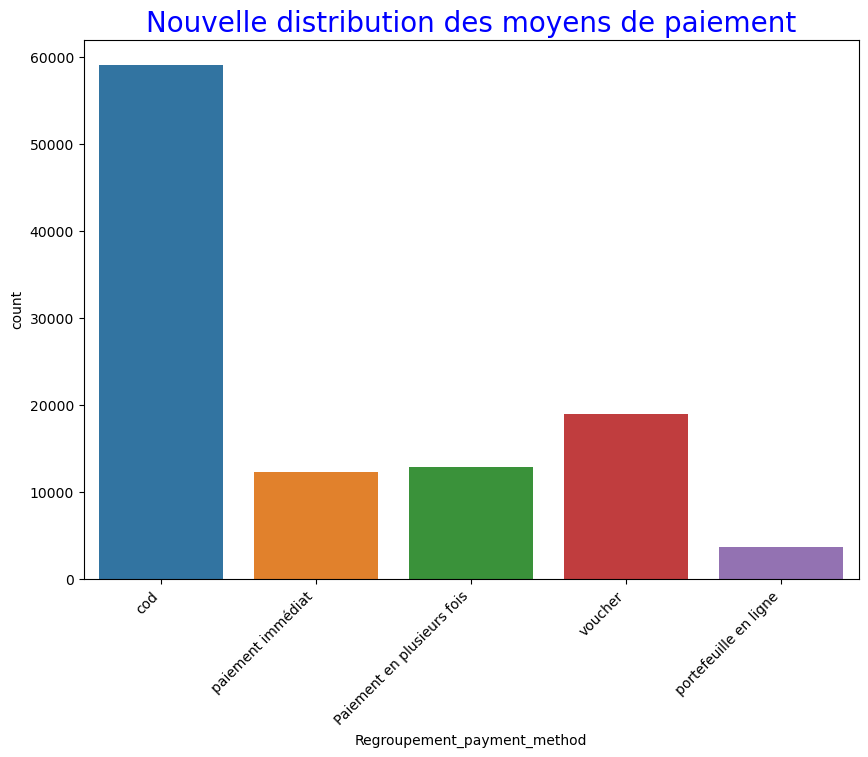

In [45]:
plt.figure(figsize=(10,7))
sns.countplot(df['Regroupement_payment_method'])
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Nouvelle distribution des moyens de paiement', fontsize=20, color='b');

##### Gestion du taux de change

Afin de faciliter la lecture des montants des transactions (roupies pakistanaises), nous avons décidé de convertir l'intégralité des transactions en euros.

Pour prendre en charge l’ensemble des transactions, nous avons utilisé le package « easy-exchange-rates », lequel contient une API permettant la récupération automatisée des taux de change du site https://exchangerate.host.

In [46]:
df["Created_at"] = df["Created_at"].apply(lambda x : pd.to_datetime(x, format='%Y%m%d'))

In [47]:
pip install easy-exchange-rates

Note: you may need to restart the kernel to use updated packages.


In [48]:
#Test de l'API sur une unique valeur

In [49]:
from easy_exchange_rates import API
api = API()
test_api = api.get_exchange_rates(
  base_currency="PKR", 
  start_date="2016-07-01", 
  end_date="2016-07-01", 
  targets=["EUR"]
)
print(test_api['2016-07-01']['EUR'])

0.008686


In [50]:
#Création de la fonction currency_converter qui sera appliquée à toutes les valeurs monétaires du dataset

In [51]:
api = API()
def currency_converter(date):
    time_series = api.get_exchange_rates(
      base_currency="PKR", 
      start_date=date, 
      end_date=date, 
      targets=["EUR"]
    )
    return time_series[date]['EUR']

In [52]:
#Création de la colonne taux_change grâce à la fonction currency converter

In [53]:
taux_change_ = np.ones(df.shape[0])
for date in pd.Series(df['Created_at'].unique()):
    change = currency_converter(date.strftime('%Y-%m-%d'))
    for i, date_creation in enumerate(df['Created_at']):
        if date_creation == date:
            taux_change_[i] = change

In [54]:
taux_change_

array([0.008686, 0.008686, 0.008686, ..., 0.006963, 0.006963, 0.006963])

In [55]:
df['Taux_change'] = taux_change_

In [56]:
#Création des nouvelles colonnes converties en euros

In [57]:
df['Discount_amount_euros'] = (df['Discount_amount'] * df['Taux_change']).round(2)
df['Net_income_euros'] = (df['Net_income'] * df['Taux_change']).round(2)
df['Price_euros'] = (df['Price'] * df['Taux_change']).round(2)

In [58]:
df.sample(1)

,Customer_id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
56654,54901,2017-07,537645,100337376,C-MUX-106847,2,27.0,0.0,1243.0,cod,2017-07-17,2017,7,Superstore,Valid,received,finalisé,cod,0.008439,0.0,10.49,0.23


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 106738 entries, 0 to 106737
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Customer_id                  106738 non-null  object        
 1   Customer since               106738 non-null  period[M]     
 2   Item_id                      106738 non-null  object        
 3   Increment_id                 106738 non-null  int64         
 4   Sales_commission_code        106738 non-null  object        
 5   Qty_ordered                  106738 non-null  int64         
 6   Price                        106738 non-null  float64       
 7   Discount_amount              106738 non-null  float64       
 8   Net_income                   106738 non-null  float64       
 9   Payment_method               106738 non-null  object        
 10  Created_at                   106738 non-null  datetime64[ns]
 11  Year                      

In [60]:
df.to_csv("preprocessing.csv",index=False)